# The (412) Index - Safety Metric (Darsh)

This notebook calculates a safety score for Pittsburgh neighborhoods using arrest counts.

Idea: fewer arrests means safer neighborhoods for young adults.

In [1]:
# Step 1: Import libraries and set plotting style
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

## Step 2: Load and inspect arrest data

In [2]:
# Read the arrest CSV
arrests = pd.read_csv('data/arrest_data.csv')

print('Rows:', len(arrests))
print(arrests.columns.tolist())
arrests.head()

Rows: 66485
['_id', 'PK', 'CCR', 'AGE', 'GENDER', 'RACE', 'ARRESTTIME', 'ARRESTLOCATION', 'OFFENSES', 'INCIDENTLOCATION', 'INCIDENTNEIGHBORHOOD', 'INCIDENTZONE', 'INCIDENTTRACT', 'COUNCIL_DISTRICT', 'PUBLIC_WORKS_DIVISION', 'X', 'Y']


,_id,PK,CCR,AGE,GENDER,RACE,ARRESTTIME,ARRESTLOCATION,OFFENSES,INCIDENTLOCATION,INCIDENTNEIGHBORHOOD,INCIDENTZONE,INCIDENTTRACT,COUNCIL_DISTRICT,PUBLIC_WORKS_DIVISION,X,Y
0,1,1975272,16158872,42.0,F,B,2016-08-24T12:20:00,"4700 Block Centre AV Pittsburgh, PA 15213",3929 Retail Theft.,"4700 Block Centre AV Pittsburgh, PA 15213",Bloomfield,5,804.0,8.0,2.0,-79.949277,40.452551
1,2,1974456,16144120,31.0,M,W,2016-08-03T14:55:00,"4200 Block Steubenville PKE Pittsburgh, PA 15205",13(a)(16) Possession of Controlled Substance,"4200 Block Steubenville PKE Pittsburgh, PA 15205",Outside City,OSC,5599.0,NaN,NaN,-80.088018,40.440136
2,3,1974466,16144165,63.0,F,B,2016-08-03T16:45:00,"900 Block Freeport RD Fox Chapel, PA 15238",3929 Retail Theft.,"900 Block Freeport RD Fox Chapel, PA 15238",Westwood,5,2811.0,9.0,2.0,-79.891803,40.486625
3,4,1974550,16145257,25.0,F,W,2016-08-05T02:36:00,"Foreland ST & Cedar AV Pittsburgh, PA 15212",5503 Disorderly Conduct. / 5505 Public Drunken...,"Foreland ST & Cedar AV Pittsburgh, PA 15212",East Allegheny,1,2304.0,1.0,1.0,-80.001939,40.454080
4,5,1974596,16145962,25.0,M,B,2016-08-06T02:00:00,"900 Block Woodlow ST Pittsburgh, PA 15205",2702 Aggravated Assault. / 2705 Recklessy Enda...,"900 Block Woodlow ST Pittsburgh, PA 15205",Crafton Heights,5,2814.0,2.0,5.0,-80.052204,40.445900


## Step 3: Clean neighborhood column

In [3]:
# Keep only rows that have a neighborhood name
arrests = arrests.dropna(subset=['INCIDENTNEIGHBORHOOD']).copy()

# Remove extra spaces and drop empty text values
arrests['INCIDENTNEIGHBORHOOD'] = arrests['INCIDENTNEIGHBORHOOD'].astype(str).str.strip()
arrests = arrests[arrests['INCIDENTNEIGHBORHOOD'] != '']

print('Rows after cleaning:', len(arrests))

Rows after cleaning: 63996


## Step 4: Count arrests by neighborhood

In [4]:
# Count number of arrests in each neighborhood
arrest_counts = arrests.groupby('INCIDENTNEIGHBORHOOD').size().reset_index(name='arrest_count')
arrest_counts = arrest_counts.rename(columns={'INCIDENTNEIGHBORHOOD': 'neighborhood'})

arrest_counts.head()

,neighborhood,arrest_count
0,Allegheny Center,1244
1,Allegheny West,130
2,Allentown,947
3,Arlington,312
4,Arlington Heights,155


## Step 5: Normalize and invert for safety score

In [5]:
# Make a 0 to 1 safety score from arrest counts
# Lower arrests should give a higher safety score
lowest = arrest_counts['arrest_count'].min()
highest = arrest_counts['arrest_count'].max()
spread = highest - lowest

if spread == 0:
    arrest_counts['safety_score'] = 1.0
else:
    arrest_counts['safety_score'] = 1 - ((arrest_counts['arrest_count'] - lowest) / spread)

safety_scores = arrest_counts[['neighborhood', 'safety_score']].sort_values('safety_score', ascending=False)
safety_scores.head(10)

,neighborhood,safety_score
57,Mt. Oliver Neighborhood,1.000000
91,Troy Hill-Herrs Island,0.999099
56,Mt. Oliver Boro,0.996395
19,Central Northside,0.995268
72,Regent Square,0.992114
73,Ridgemont,0.992114
58,New Homestead,0.991663
88,Swisshelm Park,0.990762
21,Chartiers City,0.990086
27,East Carnegie,0.989635


## Step 6: Visualize safest and least safe neighborhoods

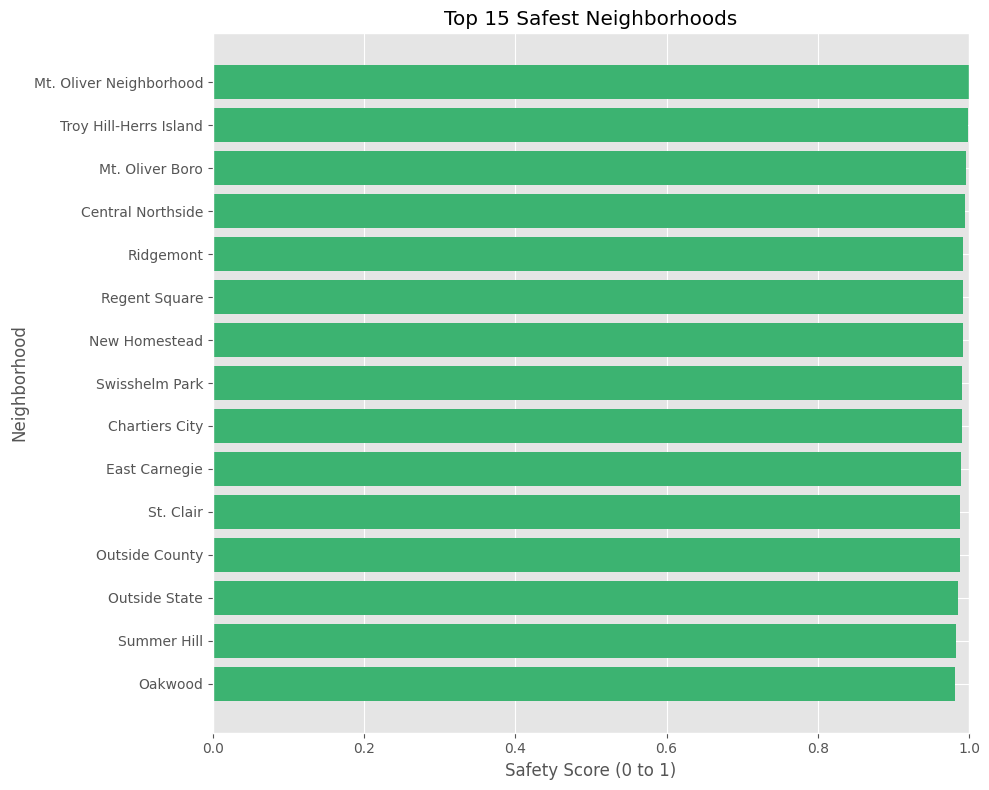

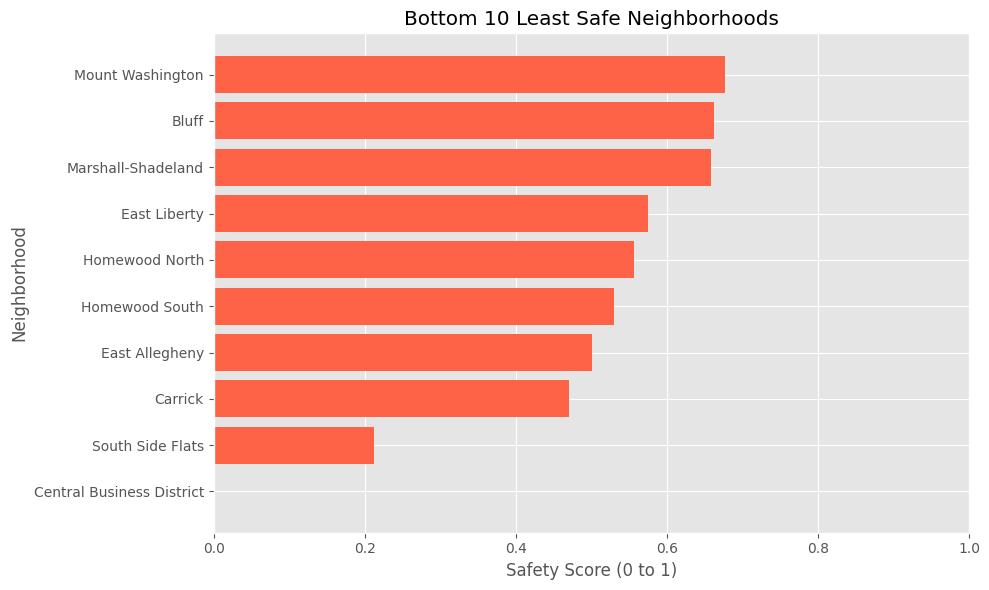

In [6]:
# Top 15 safest neighborhoods
safest_15 = safety_scores.head(15).sort_values(by='safety_score', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(safest_15['neighborhood'], safest_15['safety_score'], color='mediumseagreen')
plt.xlabel('Safety Score (0 to 1)')
plt.ylabel('Neighborhood')
plt.title('Top 15 Safest Neighborhoods')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# Bottom 10 least safe neighborhoods (still shown as horizontal for readability)
least_safe_10 = safety_scores.sort_values(by='safety_score', ascending=True).head(10)
least_safe_10 = least_safe_10.sort_values(by='safety_score', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(least_safe_10['neighborhood'], least_safe_10['safety_score'], color='tomato')
plt.xlabel('Safety Score (0 to 1)')
plt.ylabel('Neighborhood')
plt.title('Bottom 10 Least Safe Neighborhoods')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## Step 7: Save scores for final report

In [ ]:
# Save safety score table for merging later
import os
os.makedirs('scores', exist_ok=True)
safety_scores.to_csv('scores/safety_scores.csv', index=False)
print('Saved scores/safety_scores.csv')

## Conclusion

For safety, neighborhoods with fewer arrests got higher scores, and neighborhoods with more arrests got lower scores, the safest neighbourhood would be **Mt. Oliver Neighbourhood**. This is important for young adults because safety has a big impact on daily life, comfort, and overall quality of life in a new city. Even if a neighborhood has strong nightlife, it may not be the best choice if the safety score is low. Overall, this metric helps our project focus on neighborhoods that are not only fun but also safer places to live.